In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('Car Market Trends Analysis with Car Dekho Data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [2]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [4]:
df.shape

(301, 9)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [6]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [7]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')

In [8]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(2)

In [14]:
df=df.drop_duplicates()
print("Dataset size after removing duplicates:",df.shape)

Dataset size after removing duplicates: (299, 9)


In [26]:
current_year=df['Year'].max()
df['Car_Age']=current_year-df['Year']
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,4
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,5
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,1
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,7
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,4


In [27]:
current_year

np.int64(2018)

##### What are the Overall Characteristics of Dataset?

In [30]:
print("Total Car Records:", len(df))
print("Unique Car Models:", df["Car_Name"].nunique())

print("\nYear Range:")
print(df["Year"].min(), "to", df["Year"].max())

print("\nFuel Types:")
print(df["Fuel_Type"].value_counts())

print("\nSeller Types:")
print(df["Seller_Type"].value_counts())

print("\nTransmission Types:")
print(df["Transmission"].value_counts())

Total Car Records: 299
Unique Car Models: 98

Year Range:
2003 to 2018

Fuel Types:
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Seller Types:
Seller_Type
Dealer        193
Individual    106
Name: count, dtype: int64

Transmission Types:
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


##### Which Car Models are most frequently represented?

In [31]:
top_cars=df['Car_Name'].value_counts().head(10)
top_cars

Car_Name
city                         26
corolla altis                16
verna                        14
fortuner                     10
brio                         10
ciaz                          9
innova                        9
i20                           9
grand i10                     8
Royal Enfield Classic 350     7
Name: count, dtype: int64

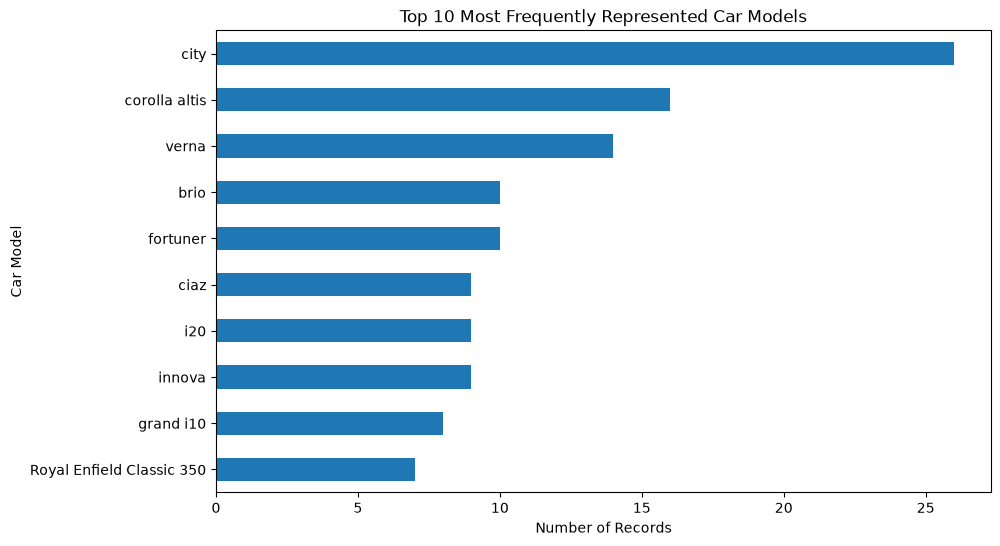

In [32]:
plt.figure(figsize=(10, 6))
top_cars.sort_values().plot(kind="barh")
plt.title("Top 10 Most Frequently Represented Car Models")
plt.xlabel("Number of Records")
plt.ylabel("Car Model")
plt.show()

##### How does car age affect selling price?

In [33]:
age_price=df.groupby("Car_Age")["Selling_Price"].mean()
age_price

Car_Age
0     9.250000
1     6.209143
2     5.161429
3     5.642500
4     4.762105
5     3.540909
6     3.841304
7     2.375263
8     5.262667
9     2.816667
10    1.002857
11    0.160000
12    1.437500
13    2.487500
14    1.500000
15    1.300000
Name: Selling_Price, dtype: float64

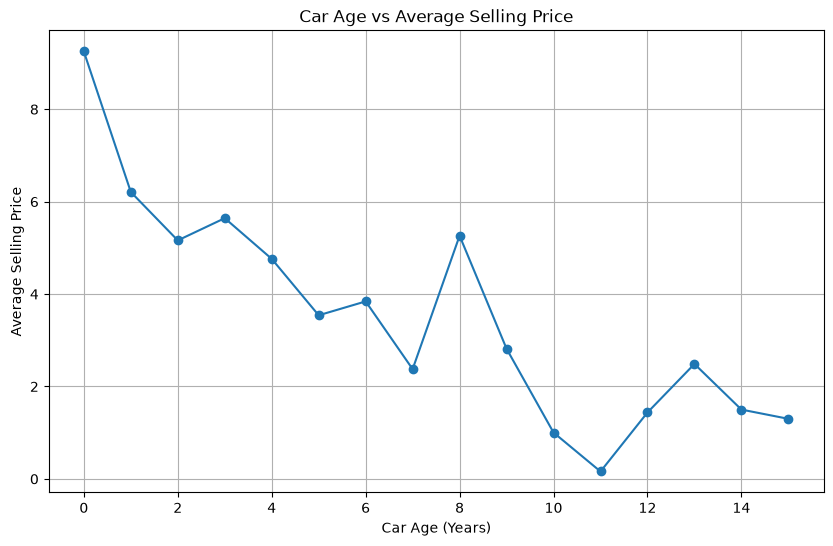

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(age_price.index, age_price.values, marker="o")
plt.title("Car Age vs Average Selling Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Average Selling Price")
plt.grid(True)
plt.show()

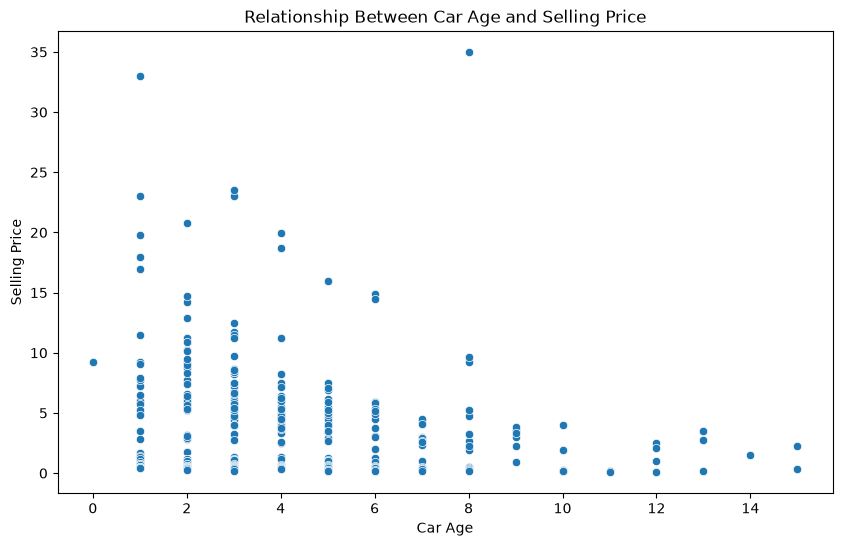

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Selling_Price"
)
plt.title("Relationship Between Car Age and Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.show()

There is a outlier in the column Kms_driven which we kept as it is

In [46]:
df['Kms_Driven'].sort_values()

133       500
165       500
166      1000
103      1200
173      1300
        ...  
77     135154
85     142000
84     197176
179    213000
196    500000
Name: Kms_Driven, Length: 299, dtype: int64

##### Which fuel type is most common and how does price vary?

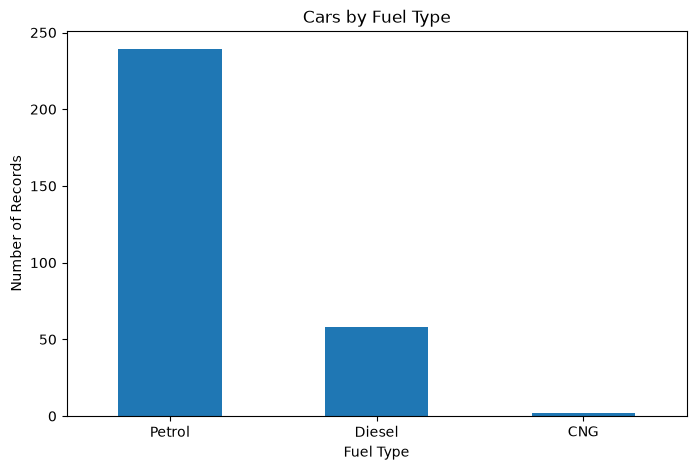

In [51]:
fuel_count = df["Fuel_Type"].value_counts()
plt.figure(figsize=(8, 5))
fuel_count.plot(kind="bar")
plt.title("Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

Fuel_Type
CNG        3.100000
Diesel    10.102759
Petrol     3.264184
Name: Selling_Price, dtype: float64


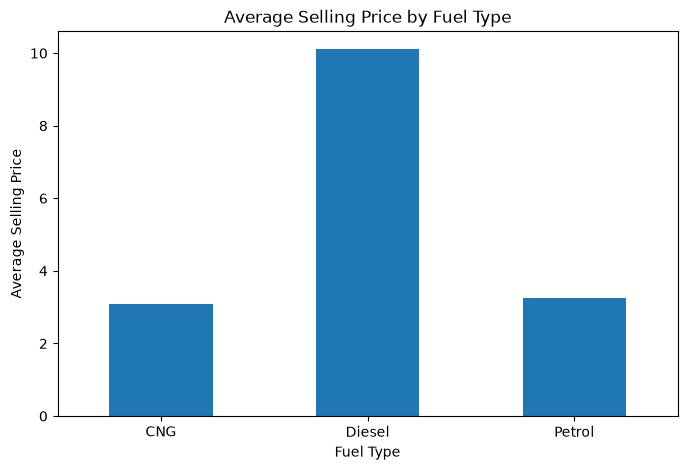

In [52]:
fuel_price = df.groupby("Fuel_Type")["Selling_Price"].mean()
print(fuel_price)
plt.figure(figsize=(8, 5))
fuel_price.plot(kind="bar")
plt.title("Average Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price")
plt.xticks(rotation=0)
plt.show()

##### Does transmission type affect selling price?

In [53]:
transmission_price = df.groupby("Transmission")["Selling_Price"].mean()
print(transmission_price)

Transmission
Automatic    9.071795
Manual       3.917308
Name: Selling_Price, dtype: float64


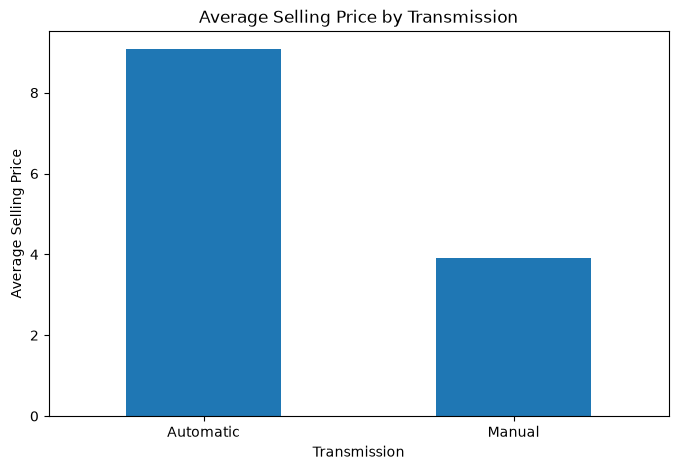

In [54]:
plt.figure(figsize=(8, 5))
transmission_price.plot(kind="bar")
plt.title("Average Selling Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Average Selling Price")
plt.xticks(rotation=0)
plt.show()

##### What is the relationship between Present Price and Selling Price?

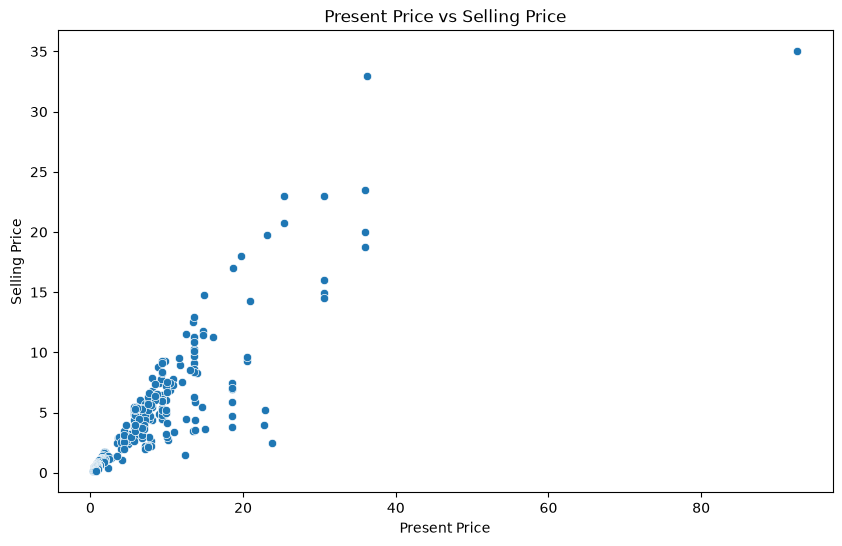

In [55]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)
plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.show()

In [56]:
price_correlation = df["Present_Price"].corr(
    df["Selling_Price"]
)
print("Correlation between Present Price and Selling Price:",round(price_correlation, 3))

Correlation between Present Price and Selling Price: 0.876


##### Which factors have the strongest relationship with selling price?

In [58]:
numeric_columns = [
    "Year",
    "Selling_Price",
    "Present_Price",
    "Kms_Driven",
    "Owner",
    "Car_Age"
]
correlation_matrix = df[numeric_columns].corr()

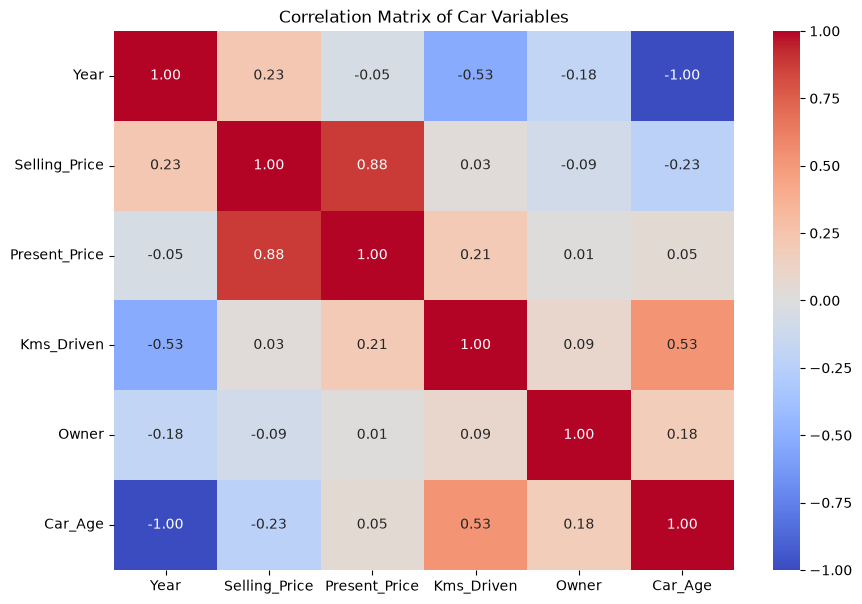

In [60]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix of Car Variables")
plt.show()

##### Fuel Type Distribution

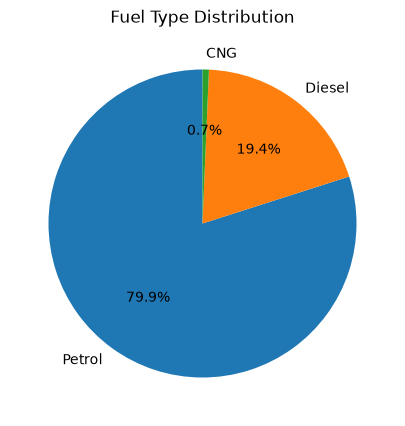

In [62]:
fuel_count = df["Fuel_Type"].value_counts()
plt.figure(figsize=(5,5))
plt.pie(
    fuel_count,
    labels=fuel_count.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Fuel Type Distribution")
plt.show()

### Summary

In [63]:
summary = {
    "Total Records": len(df),
    "Unique Car Models": df["Car_Name"].nunique(),
    "Most Common Fuel Type": df["Fuel_Type"].mode()[0],
    "Most Common Transmission": df["Transmission"].mode()[0],
    "Most Common Seller Type": df["Seller_Type"].mode()[0],
    "Average Selling Price": df["Selling_Price"].mean(),
    "Average Present Price": df["Present_Price"].mean(),
    "Average Kms Driven": df["Kms_Driven"].mean()
}
summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)
summary_df

,Metric,Value
0,Total Records,299
1,Unique Car Models,98
2,Most Common Fuel Type,Petrol
3,Most Common Transmission,Manual
4,Most Common Seller Type,Dealer
5,Average Selling Price,4.589632
6,Average Present Price,7.541037
7,Average Kms Driven,36916.752508
